#  Student Performance Analysis & Prediction (Real Dataset)

This notebook explores a real-world student performance dataset and builds machine learning models to:

- Analyze factors affecting student performance  
- Predict student grades (Classification)  
- Handle class imbalance using advanced techniques (SMOTE, class weights)  
- Compare multiple models and evaluate their performance  

---

##  Key Learning Goals

- Understand real-world data challenges  
- Perform feature engineering and preprocessing  
- Build and evaluate ML models  
- Handle imbalanced datasets  
- Develop a prediction + recommendation system  

---

##  Dataset

Source: Kaggle – *Students Performance in Exams*

---

##  Important Note

This dataset has limitations:
- No direct study-related features (e.g., study hours)
- Weak correlation between features and performance

 This affects model accuracy and reflects real-world ML challenges

In [38]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../dataset/StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [3]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [4]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

We are going to predict average score.

In [6]:
df["average_score"] = df[["math_score", "reading_score", "writing_score"]].mean(axis=1)

df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


There are 1000 rows. We have 5 categorical variables and 3 numberical variables and 1 derived variable.

Compared to the synthetic dataset, the Kaggle dataset introduces categorical variables, indirect features, and real-world noise, requiring encoding, better preprocessing, and more careful feature interpretation.

In [7]:
#Data Preparation for Modeling
X = df.drop(columns = ["math_score", "reading_score", "writing_score", "average_score"])
y = df["average_score"]

Concept- One-Hot Encoding

gender_male   gender_female
     1               0
     0               1

In [8]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school,lunch_standard,test_preparation_course_none
0,False,True,False,False,False,True,False,False,False,False,True,True
1,False,False,True,False,False,False,False,False,True,False,True,False
2,False,True,False,False,False,False,False,True,False,False,True,True
3,True,False,False,False,False,False,False,False,False,False,False,True
4,True,False,True,False,False,False,False,False,True,False,True,True


now 12 columns in X after encoding (if we dont use drop_first) and the number of columns increased because each categorical value is converted into a separate binary column, increasing dimensionality. and Without encoding, machine learning models cannot process categorical data. Additionally, improper encoding like label encoding may introduce false ordinal relationships, leading to biased predictions.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.2, random_state = 42)

In [10]:
#linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
#predictions
y_pred = model.predict(X_test)

# print("predictions:", y_pred)
# print("Actual values:", y_test.values)


MAE provides an interpretable measure of average error, while MSE penalizes larger errors more heavily. RMSE is often preferred because it maintains unit consistency while still emphasizing large deviations.

In [12]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)



print("MAE:", mae)
print("R2 Score:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 10.490182374209294
R2 Score: 0.16217185763155217
MSE: 179.60234233623538
RMSE: 13.401579844788277


We got MAE = 10.490, R2 score = 0.16, MSE = 179.60, RMSE = 13.40.
MAE: On average, your prediction is off by ~10.5 marks.
RMSE: Large errors are present (since RMSE > MAE). Some predictions are very wrong
R2: model explains only 16% of the variation in student performance.

Performance dropped Reasons:
Reason 1: Real-World Data is Noisy.
Reason 2: Missing Important Features.
Reason 3: Weak Feature Relationships.
Reason 4: Linear Model Limitation: real-data is non-linear.

In [13]:
#Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [14]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("RF MAE:", mae_rf)
print("RF RMSE:", rmse_rf)
print("RF R2:", r2_rf)

RF MAE: 11.480718162177617
RF RMSE: 14.776901832099448
RF R2: -0.01861419507194917


 Did Random Forest improve MAE?
 ans: NO.
 Did R² increase?
 ans: no, The model is performing worse than simply predicting the average value
 Which model is better?
 ans: Linear Regression is clearly better here
 
 ✔️ Lower error
 ✔️ Positive R²
 ✔️ More stable
 WHY RANDOM FOREST FAILED (VERY IMPORTANT)
 Reason 1: Data is Weak (Not Model’s Fault)
    gender
    lunch
    parental education
    These are not strong predictors
Reason 2: Random Forest Needs Signal
    Random Forest works well when:
    Clear patterns exist
    Complex interactions exist
    Here:
    Patterns are weak and noisy
Reason 3: Overfitting
    Random Forest:
    Learns training data too well
    Fails on test data
    Especially when:
    Data is small (1000 isn’t huge for RF)
    Features are weak
Reason 4: Feature Engineering Missing
    Raw features only

    But real ML requires:
    Combining features
    Creating meaningful signals


Random Forest underperformed because the dataset lacks strong predictive features, and the model likely overfit to weak patterns in the training data, resulting in poor generalization.

FEATURE ENGINEERING
We need to extract more signal from data.

In [15]:
# Encode test preparation as binary variable
df["test_preparation_done"] = df["test_preparation_course"].apply(lambda x: 1 if x == "completed" else 0)

#Encode lunch Quality as binary variable
df["lunch_quality"] = df["lunch"].apply(lambda x: 1 if x == "standard" else 0)

df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score,test_preparation_done,lunch_quality
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,0,1
1,female,group C,some college,standard,completed,69,90,88,82.333333,1,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,0,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,0,0
4,male,group C,some college,standard,none,76,78,75,76.333333,0,1


In [16]:
X = df.drop(columns = ["math_score", "reading_score", "writing_score", "average_score", "test_preparation_course", "lunch"])
# df.columns
X = pd.get_dummies(X, drop_first=False)
X.head()

,test_preparation_done,lunch_quality,gender_female,gender_male,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental_level_of_education_associate's degree,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school
0,0,1,True,False,False,True,False,False,False,False,True,False,False,False,False
1,1,1,True,False,False,False,True,False,False,False,False,False,False,True,False
2,0,1,True,False,False,True,False,False,False,False,False,False,True,False,False
3,0,0,False,True,True,False,False,False,False,True,False,False,False,False,False
4,0,1,False,True,False,False,True,False,False,False,False,False,False,True,False


In [17]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [18]:
model1 = LinearRegression()
model1.fit(X_train_new, y_train_new)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
#Prediction
y_pred_new = model1.predict(X_test_new)

#Evaluation
mae_new = mean_absolute_error(y_test_new, y_pred_new)
r2_new = r2_score(y_test_new, y_pred_new)
mse_new = mean_squared_error(y_test_new, y_pred_new)
rmse_new = mse_new ** 0.5

print("MAE:", mae_new)
print("R2 Score:", r2_new)
print("MSE:", mse_new)
print("RMSE:", rmse_new)

MAE: 10.490182374209294
R2 Score: 0.16217185763155217
MSE: 179.60234233623538
RMSE: 13.401579844788277


Same as before, We need to create new features

In [ ]:
# Academic consistency
df["score_variance"] = df[["math_score", "reading_score", "writing_score"]].std(axis=1)

# Total score (strong signal)
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]

df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,test_preparation_done,lunch_quality,average_score,score_variance,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,0,1,72.666667,1.154701,218
1,female,group C,some college,standard,completed,69,90,88,1,1,82.333333,11.590226,247
2,female,group B,master's degree,standard,none,90,95,93,0,1,92.666667,2.516611,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,0,0,49.333333,6.806859,148
4,male,group C,some college,standard,none,76,78,75,0,1,76.333333,1.527525,229


In [ ]:
# Since target = average_score and total_score contains same info therefore we need to remove total_score
df.drop(columns=["total_score"], inplace=True)
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'test_preparation_done', 'lunch_quality',
       'average_score', 'score_variance'],
      dtype='str')

In [ ]:
# Education level mapping (ordinal)
education_map = {
    "some high school": 1,
    "high school": 2,
    "some college": 3,
    "associate's degree": 4,
    "bachelor's degree": 5,
    "master's degree": 6
}

df["parent_education_level"] = df["parental_level_of_education"].map(education_map)

In [ ]:
X = df.drop(columns=[
    "math_score", "reading_score", "writing_score",
    "average_score",
    "parental_level_of_education"
])

X = pd.get_dummies(X)

In [ ]:
X_train_new1, X_test_new1, y_train_new1, y_test_new1 = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
model2 = LinearRegression()
model2.fit(X_train_new1, y_train_new1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#Prediction
y_pred_new1 = model2.predict(X_test_new1)

#Evaluation
mae_new1 = mean_absolute_error(y_test_new1, y_pred_new1)
r2_new1 = r2_score(y_test_new1, y_pred_new1)
mse_new1 = mean_squared_error(y_test_new1, y_pred_new1)
rmse_new1 = mse_new1 ** 0.5

print("MAE:", mae_new1)
print("R2 Score:", r2_new1)
print("MSE:", mse_new1)
print("RMSE:", rmse_new1)

MAE: 10.302414712151311
R2 Score: 0.18559197607414712
MSE: 174.58185195476963
RMSE: 13.212942592578296


Regularization (Ridge Regression)
Model may:
Overfit weak signals
Give unstable coefficients
Ridge fixes this

In [ ]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_new1, y_train_new1)

y_pred_ridge = ridge_model.predict(X_test_new1)

mae_ridge = mean_absolute_error(y_test_new1, y_pred_ridge)
r2_ridge = r2_score(y_test_new1, y_pred_ridge)

print("Ridge MAE:", mae_ridge)
print("Ridge R2:", r2_ridge)

Ridge MAE: 10.302029384253393
Ridge R2: 0.18569048254852527


***Both Linear and Ridge Regression gave similar performance, indicating low model variance and minimal overfitting. The limiting factor is the dataset, which lacks strong predictive features, resulting in low R².***

*Convert Regression → Classification*

In [24]:
def assign_grade(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    elif score >= 70:
        return 'C'
    elif score >= 60:
        return 'D'
    else:
        return 'F'

df.head()
    
df["grade"] = df["average_score"].apply(assign_grade)
df[["average_score", "grade"]].head()

,average_score,grade
0,72.666667,C
1,82.333333,B
2,92.666667,A
3,49.333333,F
4,76.333333,C


In [25]:
df["grade"].value_counts()


grade
F    285
C    261
D    256
B    146
A     52
Name: count, dtype: int64

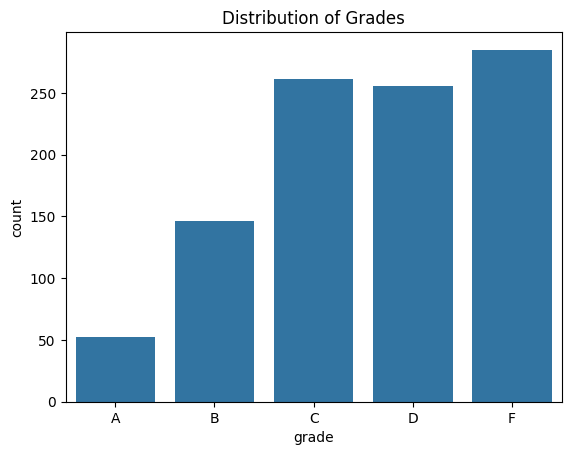

In [26]:
sns.countplot(x="grade", data=df,  order=["A", "B", "C", "D", "F"])
plt.title("Distribution of Grades")
plt.show()

Dataset is class imbalanced
we may get high accuracy but poor real performance. The dataset is imbalanced with a higher concentration of lower grades (C, D, F) and very few high grades (A)

In [27]:
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'average_score', 'test_preparation_done',
       'lunch_quality', 'grade'],
      dtype='str')

In [28]:
X = df.drop(columns=[
    "math_score", "reading_score", "writing_score",
    "average_score", "grade"
])

y = df["grade"]

In [29]:
X = pd.get_dummies(X)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
clf = LogisticRegression(max_iter=2000, class_weight='balanced')
clf.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [36]:
y_pred = clf.predict(X_test_scaled)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.35
              precision    recall  f1-score   support

           A       0.06      0.50      0.11         4
           B       0.20      0.30      0.24        27
           C       0.41      0.20      0.27        59
           D       0.43      0.19      0.26        48
           F       0.51      0.63      0.56        62

    accuracy                           0.35       200
   macro avg       0.32      0.36      0.29       200
weighted avg       0.41      0.35      0.35       200



*Improving class balance often reduces accuracy but improves the model’s ability to correctly identify minority classes.*

In [39]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.245
              precision    recall  f1-score   support

           A       0.15      0.50      0.24         4
           B       0.15      0.07      0.10        27
           C       0.31      0.29      0.30        59
           D       0.14      0.15      0.14        48
           F       0.30      0.34      0.32        62

    accuracy                           0.24       200
   macro avg       0.21      0.27      0.22       200
weighted avg       0.24      0.24      0.24       200



Tree-based models do not guarantee better performance, especially when features are weak and dataset size is limited.

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.24
              precision    recall  f1-score   support

           A       0.08      0.50      0.14         4
           B       0.14      0.15      0.15        27
           C       0.31      0.24      0.27        59
           D       0.17      0.15      0.16        48
           F       0.34      0.34      0.34        62

    accuracy                           0.24       200
   macro avg       0.21      0.27      0.21       200
weighted avg       0.26      0.24      0.24       200



Simpler models often outperform complex ones when the dataset has limited predictive power and mostly linear relationships.

**Method SMOTE**


Instead of weighting classes, we generate Synthetic Samples for minority classes

In [41]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [44]:
scaler = StandardScaler()

X_resampled_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

In [77]:
clf = LogisticRegression(max_iter=2000)
clf.fit(X_resampled_scaled, y_resampled)

y_pred = clf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.395
              precision    recall  f1-score   support

           A       0.09      0.25      0.13         4
           B       0.26      0.19      0.22        27
           C       0.39      0.41      0.40        59
           D       0.35      0.23      0.28        48
           F       0.49      0.61      0.55        62

    accuracy                           0.40       200
   macro avg       0.32      0.34      0.31       200
weighted avg       0.39      0.40      0.39       200



Although the baseline model achieved higher accuracy, it suffered from class imbalance and poor recall for minority classes. Using SMOTE improved class balance and overall robustness, making the model more reliable despite a slight drop in accuracy

***Build Pipeline***

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

pipeline.fit(X_resampled, y_resampled)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.395
              precision    recall  f1-score   support

           A       0.09      0.25      0.13         4
           B       0.26      0.19      0.22        27
           C       0.39      0.41      0.40        59
           D       0.35      0.23      0.28        48
           F       0.49      0.61      0.55        62

    accuracy                           0.40       200
   macro avg       0.32      0.34      0.31       200
weighted avg       0.39      0.40      0.39       200



In the pipeline, scaling is handled automatically as part of the transformation steps. The StandardScaler is applied during both fit and predict phases, ensuring consistency without manually transforming the data.Pipeline is safer because it ensures consistent preprocessing across training and inference, prevents data leakage by fitting transformations only on training data, and reduces human errors by automating the workflow.

***After analysis, the prediction system is prepared.***

In [53]:
new_student = pd.DataFrame({
    "gender": ["male"],
    "race/ethnicity": ["group C"],
    "parental level of education": ["bachelor's degree"],
    "lunch": ["standard"],
    "test preparation course": ["completed"]
})

In [54]:
new_student_encoded = pd.get_dummies(new_student)

# Align columns with training data
new_student_encoded = new_student_encoded.reindex(columns=X.columns, fill_value=0)

In [79]:
prediction = pipeline.predict(new_student_encoded)
print("Predicted Grade:", prediction[0])

Predicted Grade: A


***Recommendation System***

In [62]:
def recommend(student):
    recommendations = []

    if student["test preparation course"] == "none":
        recommendations.append("Complete a test preparation course")

    if student["lunch"] == "free/reduced":
        recommendations.append("Ensure proper nutrition for better focus")

    if student["parental level of education"] in ["some high school", "high school"]:
        recommendations.append("Seek additional academic guidance or mentorship")

    # NEW: default message
    if len(recommendations) == 0:
        recommendations.append("Keep up the good work! Maintain your current habits.")

    return recommendations

In [63]:
rec = recommend(new_student.iloc[0])
print("Recommendations:")
for r in rec:
    print("-", r)

Recommendations:
- Keep up the good work! Maintain your current habits.


***Combined Version***

In [73]:
def predict_and_recommend(student_df):
    student_encoded = pd.get_dummies(student_df)
    student_encoded = student_encoded.reindex(columns=X.columns, fill_value=0)

    prediction = pipeline.predict(student_encoded)
    recommendations = recommend(student_df.iloc[0])

    return prediction, recommendations

In [84]:
grade, recs = predict_and_recommend(new_student)

print("Predicted Grade:", grade)
print("Recommendations:")
for r in recs:
    print("-", r)

Predicted Grade: ['A']
Recommendations:
- Keep up the good work! Maintain your current habits.


***for deployment purpose***

In [81]:
import joblib
joblib.dump(pipeline, "student_performance_model.pkl")

['student_performance_model.pkl']